In [1]:
import numpy as np

class Contour:
    """
    Представление комплексного контура.
    Поля:
        attribute   – произвольный атрибут (сохраняется при эквализации)
        length      – количество сегментов (векторов)
        norm        – евклидова норма контура (sqrt(sum(|z|^2)))
        complex_code – массив NumPy комплексных чисел (dtype=complex128) длины length
    """
    def __init__(self, attribute=None, length=0, norm=0.0, complex_code=None):
        self.attribute = attribute
        self.length = length
        self.norm = norm
        self.complex_code = complex_code if complex_code is not None else np.array([], dtype=np.complex128)


def complex_contour_length(contour: Contour) -> float:
    """
    Вычисляет полную длину контура как сумму модулей всех сегментов.
    Используется векторизованная функция np.abs и np.sum.
    """
    return float(np.sum(np.abs(contour.complex_code[:contour.length])))


def contour_norm(contour: Contour) -> float:
    """
    Вычисляет норму контура (sqrt(sum(|z|^2))) и обновляет поле norm.
    Используется np.linalg.norm для комплексных чисел.
    """
    norm = float(np.linalg.norm(contour.complex_code[:contour.length]))
    contour.norm = norm
    return norm


def complex_contour_equalization(size: int, contour_i: Contour) -> Contour:
    """
    Выполняет эквализацию контура – передискретизацию на заданное число сегментов
    с примерно равными длинами.

    Параметры:
        size      – желаемое количество сегментов в результирующем контуре
        contour_i – исходный контур (объект Contour)

    Возвращает:
        Новый контур Contour с эквализированными сегментами.
    """
    total_length = complex_contour_length(contour_i)
    if size <= 0 or total_length == 0:
        # Некорректный размер или пустой контур – возвращаем пустой результат
        return Contour(attribute=contour_i.attribute, length=0, complex_code=np.array([]))

    # Желаемая длина каждого нового сегмента
    vector_length = total_length / size

    # Массив для новых векторов (заполняется постепенно)
    res_code = np.zeros(size, dtype=np.complex128)

    # Переменные, соответствующие Pascal-коду
    vector_origin_x = 0.0
    vector_origin_y = 0.0
    current_x = 0.0
    current_y = 0.0
    j = 0
    remainder = 0.0
    vector_extremity_x = 0.0
    vector_extremity_y = 0.0

    # Проход по сегментам исходного контура
    for i in range(contour_i.length):
        z = contour_i.complex_code[i]
        re = z.real
        im = z.imag
        standard_length = abs(z)          # длина текущего сегмента

        remainder += standard_length
        vector_extremity_x += re
        vector_extremity_y += im
        current_x += re
        current_y += im

        # Пока накопленная длина позволяет сформировать новый сегмент
        while (remainder >= vector_length) and (j < size):
            ratio = (remainder - vector_length) / standard_length

            # Координаты нового вектора (интерполяция)
            new_re = vector_extremity_x - re * ratio
            new_im = vector_extremity_y - im * ratio
            res_code[j] = new_re + 1j * new_im

            # Обновление остатка вектора
            vector_extremity_x = re * ratio
            vector_extremity_y = im * ratio

            # Накопление суммы новых векторов
            vector_origin_x += new_re
            vector_origin_y += new_im

            remainder -= vector_length
            j += 1

    # Завершение: корректировка последнего сегмента или добавление остатка
    if j == size:
        # Все сегменты уже созданы – добавляем остаток к последнему
        last = res_code[j - 1]
        res_code[j - 1] = (last.real + (current_x - vector_origin_x)) + \
                          1j * (last.imag + (current_y - vector_origin_y))
    else:
        # Есть место для ещё одного сегмента – добавляем остаток как новый
        new_re = current_x - vector_origin_x
        new_im = current_y - vector_origin_y
        res_code[j] = new_re + 1j * new_im
        j += 1

    # Формирование результирующего контура
    contour_r = Contour()
    contour_r.attribute = contour_i.attribute
    contour_r.length = j
    contour_r.complex_code = res_code[:j]   # обрезаем до фактического размера
    contour_r.norm = np.linalg.norm(contour_r.complex_code)   # вычисляем норму через numpy

    return contour_r

In [2]:
# Пример создания контура (три сегмента: (1+0j), (0+1j), (-1+0j))
code = np.array([1+0j, 0+1j, -1+0j], dtype=np.complex128)
contour = Contour(attribute="triangle", length=3, complex_code=code)
contour.norm = contour_norm(contour)  # заполняем поле norm

# Эквализация до 5 сегментов
new_contour = complex_contour_equalization(5, contour)
print(new_contour.length)           # 5
print(new_contour.complex_code)     # массив новых комплексных векторов
print(new_contour.norm)             # норма нового контура

5
[ 0.6+0.j   0.4+0.2j  0. +0.6j -0.4+0.2j -0.6+0.j ]
1.2165525060596438


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_contour(contour, title="Контур", show_vectors=False, ax=None, arrow_scale=1.0):
    """
    Визуализация комплексного контура на плоскости.

    Параметры:
        contour       – объект Contour (с полем complex_code и length)
        title         – заголовок графика
        show_vectors  – если True, каждый сегмент рисуется как стрелка
        ax            – оси matplotlib (если None, создаются новые)
        arrow_scale   - масштаб стрелок
    """
    if contour.length == 0 or len(contour.complex_code) == 0:
        print("Контур пуст, визуализация невозможна.")
        return

    # Вычисляем координаты точек (кумулятивная сумма векторов)
    points = np.cumsum(contour.complex_code[:contour.length])
    # Добавляем начальную точку (0,0)
    points = np.concatenate([[0+0j], points])
    x = points.real
    y = points.imag

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    # Рисуем ломаную
    ax.plot(x, y, 'bo-', label='Контур', linewidth=2, markersize=6)

    if show_vectors:
        # Для каждого сегмента добавляем стрелку от предыдущей точки к следующей
        for i in range(len(x)-1):
            ax.arrow(x[i], y[i], x[i+1]-x[i], y[i+1]-y[i],
                     head_width=0.05*arrow_scale, head_length=0.08*arrow_scale, fc='red', ec='red',
                     length_includes_head=True, alpha=0.7)

    # Отметим начало и конец
    ax.plot(x[0], y[0], 'go', markersize=20, label='Старт')
    ax.plot(x[-1], y[-1], 'ro', markersize=10, label='Финиш')

    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_title(title)
    ax.legend()
    ax.set_xlabel('Re')
    ax.set_ylabel('Im')

    if ax is None:
        plt.show()
    else:
        return fig, ax

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Эквализированный контур (9 сегментов)'}, xlabel='Re', ylabel='Im'>)

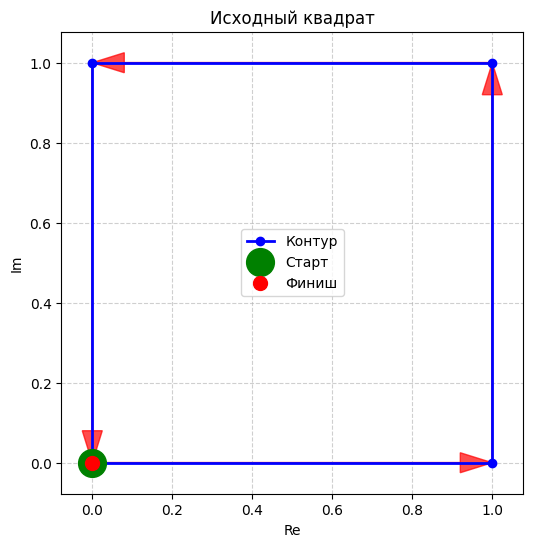

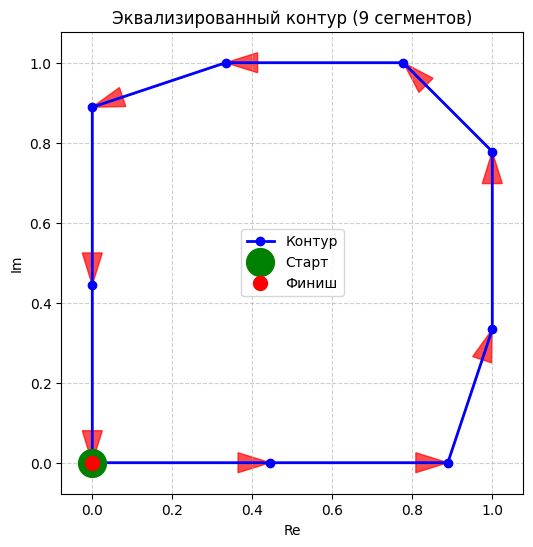

In [4]:
# Пример использования визуализации контуров

# Создадим тестовый контур (квадрат)
code = np.array([1+0j, 0+1j, -1+0j, 0-1j], dtype=np.complex128)
contour = Contour(attribute="square", length=4, complex_code=code)
contour.norm = contour_norm(contour)

# Визуализация без стрелок
visualize_contour(contour, title="Исходный квадрат", show_vectors=True)

# Эквализация до 9 сегментов
eq_contour = complex_contour_equalization(9, contour)

# Визуализация со стрелками
visualize_contour(eq_contour, title="Эквализированный контур (9 сегментов)", show_vectors=True)

In [5]:
def opencv_contour_to_our_contour(opencv_contour, attribute=None):
    """
    Преобразует контур из OpenCV (массив точек) в наш класс Contour.
    Возвращает объект Contour, где complex_code – массив комплексных векторов.
    """
    points = opencv_contour.squeeze()  # (N, 2)
    if len(points) < 2:
        return None  # вырожденный контур

    # Вычисляем векторы как разности соседних точек (замыкаем контур)
    # Для замкнутого контура: последний вектор соединяет последнюю точку с первой
    vectors = []
    for i in range(len(points)):
        x1, y1 = points[i]
        y1 = - y1
        x2, y2 = points[(i+1) % len(points),0], points[(i+1) % len(points),1]  # замыкание
        y2 = - y2
        vectors.append(complex(x2 - x1, y2 - y1))

    vec_array = np.array(vectors, dtype=np.complex128)
    contour = Contour(attribute=attribute, length=len(vec_array), complex_code=vec_array)
    contour.norm = contour_norm(contour)
    return contour

[[[3 1]]

 [[2 2]]

 [[2 3]]

 [[3 4]]

 [[2 5]]

 [[3 4]]

 [[4 5]]

 [[5 6]]

 [[6 7]]

 [[5 6]]

 [[4 5]]

 [[4 4]]

 [[5 3]]

 [[6 4]]

 [[5 3]]

 [[4 2]]]


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Эквализированный контур'}, xlabel='Re', ylabel='Im'>)

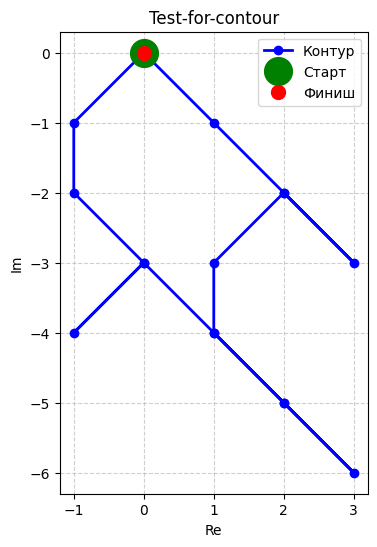

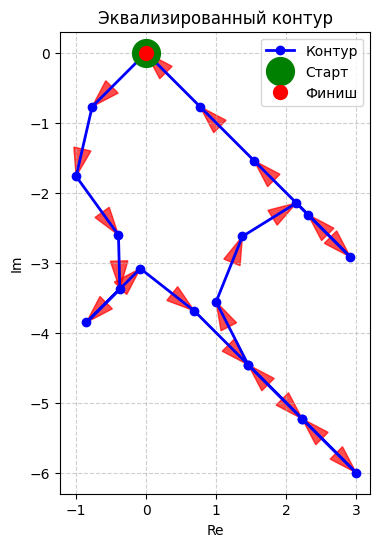

In [7]:
# Пример использования преобразователя контуров
import sys
import numpy as np
import cv2 as cv


# 1. Загрузка изображения в оттенках серого
image = cv.imread('Test-for-contour.png', cv.IMREAD_GRAYSCALE)

# 2. Применение простой пороговой обработки
# Пиксели < 127 становятся черными (0), а >= 127 - белыми (255)
ret, thresh = cv.threshold(image, 127, 255, cv.THRESH_BINARY)

# 3. Ищем контуры и складируем их в переменную contours
contours, hierarchy = cv.findContours( thresh.copy(), cv.RETR_TREE, cv.CHAIN_APPROX_NONE)
print(contours[0])

# 4. Преобразуем массив точек контура в экзезмпляр нашего класса
contour = opencv_contour_to_our_contour(contours[0], attribute=None)

# Визуализация
visualize_contour(contour, title="Test-for-contour")

# Эквализация
eq_contour = complex_contour_equalization(20, contour)

# Визуализация со стрелками
visualize_contour(eq_contour, title="Эквализированный контур", show_vectors=True, arrow_scale=5)

# отображаем контуры поверх изображения
# cv.drawContours(image, contours, -1, (255,0,0), 3, cv.LINE_AA, hierarchy, 1 )
# cv.imshow('contours', image) # выводим итоговое изображение в окно
# cv.waitKey(0)

Исходная норма: 2.0
Новая норма: 4.0


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Повёрнут и масштабирован относительно (0,0)'}, xlabel='Re', ylabel='Im'>)

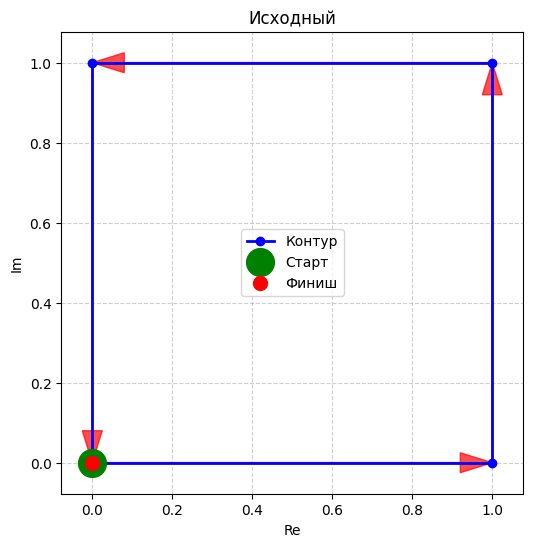

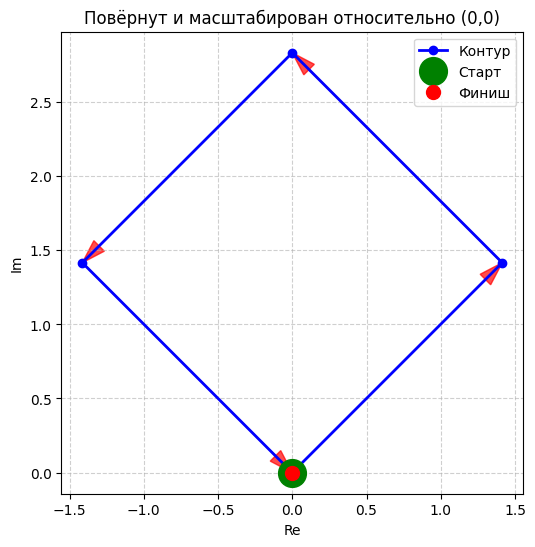

In [8]:
import numpy as np

def transform_contour(contour, scale=1.0, angle=0.0):
    """
    Выполняет поворот и масштабирование контура относительно начала координат.

    Параметры:
        contour – объект Contour
        scale   – коэффициент масштабирования (по умолчанию 1.0)
        angle   – угол поворота в радианах (по умолчанию 0.0)

    Возвращает:
        Новый объект Contour с преобразованными векторами.
    """
    if contour.length == 0:
        return Contour(attribute=contour.attribute, length=0, complex_code=np.array([]))

    # Комплексный множитель: поворот и масштабирование
    factor = scale * np.exp(1j * angle)

    # Умножаем все векторы на factor (поворот и масштабирование относительно начала координат)
    new_code = contour.complex_code[:contour.length] * factor

    # Создаём новый контур
    new_contour = Contour(
        attribute=contour.attribute,
        length=len(new_code),
        complex_code=np.array(new_code, dtype=np.complex128)
    )
    # Пересчитываем норму (она масштабируется пропорционально |scale|)
    new_contour.norm = contour_norm(new_contour)
    return new_contour


# ========== Пример использования ==========

# Квадрат (векторы: (1,0), (0,1), (-1,0), (0,-1))
code = np.array([1+0j, 0+1j, -1+0j, 0-1j], dtype=np.complex128)
contour = Contour(attribute="square", length=4, complex_code=code)
contour.norm = contour_norm(contour)
scale_const = 2.0

# Поворот на 45° и масштабирование в 2 раза
transformed = transform_contour(contour, scale=scale_const, angle=np.pi/4)

print("Исходная норма:", contour.norm)
print("Новая норма:", transformed.norm)  # должна быть в 2 раза больше

# Визуализация
visualize_contour(contour, title="Исходный", show_vectors=True, arrow_scale=1)
visualize_contour(transformed, title="Повёрнут и масштабирован относительно (0,0)", show_vectors=True, arrow_scale=scale_const)

In [9]:
'''
Банк эталонных контуров: сохранение и загрузка
'''
import json
import numpy as np

def add_contour_to_bank(contour, label, bank_path='contour_bank.json'):
    """
    Добавляет эталонный контур в файл-банк.

    Параметры:
        contour   – объект класса Contour
        label     – строка или число, идентифицирующая класс/объект
        bank_path – путь к JSON-файлу банка (если не существует – создаётся)
    """
    # Формируем запись для одного контура
    entry = {
        'label': str(label),
        'attribute': contour.attribute,
        'length': contour.length,
        'norm': float(contour.norm),
        'complex_code': [
            {'real': z.real, 'imag': z.imag}
            for z in contour.complex_code[:contour.length]
        ]
    }

    # Загружаем существующий банк (если есть)
    try:
        with open(bank_path, 'r', encoding='utf-8') as f:
            bank = json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        bank = []  # если файла нет или он повреждён, начинаем новый

    bank.append(entry)

    # Сохраняем обратно
    with open(bank_path, 'w', encoding='utf-8') as f:
        json.dump(bank, f, indent=2, ensure_ascii=False)


def load_contours_from_bank(bank_path='contour_bank.json'):
    """
    Загружает все эталонные контуры из файла банка.

    Возвращает:
        Список кортежей (label, contour), где contour – объект Contour.
    """
    try:
        with open(bank_path, 'r', encoding='utf-8') as f:
            bank = json.load(f)
    except (FileNotFoundError, json.JSONDecodeError):
        return []  # банк пуст или не существует

    contours = []
    for entry in bank:
        # Восстанавливаем массив комплексных чисел
        complex_list = [
            complex(item['real'], item['imag'])
            for item in entry['complex_code']
        ]
        code = np.array(complex_list, dtype=np.complex128)

        # Создаём объект Contour
        contour = Contour()
        contour.attribute = entry.get('attribute', None)
        contour.length = entry.get('length', len(code))
        contour.norm = entry.get('norm', np.linalg.norm(code))
        contour.complex_code = code[:contour.length]  # защита от несоответствия длины

        # Добавляем пару (метка, контур)
        contours.append((entry['label'], contour))

    return contours


'''
Вспомогательная функция для быстрого поиска контуров по метке
'''
def get_contours_by_label(label, bank_path='contour_bank.json'):
    """
    Возвращает список контуров из банка, у которых метка совпадает с заданной.
    """
    all_contours = load_contours_from_bank(bank_path)
    return [cnt for lbl, cnt in all_contours if lbl == str(label)]

In [10]:
'''
Пример использования банка контуров
'''
# Предположим, у нас есть несколько эквализированных контуров
square_contour = complex_contour_equalization(30, some_contour)
circle_contour  = complex_contour_equalization(30, some_other_contour)

# Добавляем их в банк с метками
add_contour_to_bank(square_contour, label='square')
add_contour_to_bank(circle_contour,  label='circle')

# Загружаем все эталоны
bank = load_contours_from_bank()
for label, cnt in bank:
    print(f"Метка: {label}, длина: {cnt.length}, норма: {cnt.norm:.4f}")

# Получаем только квадраты
squares = get_contours_by_label('square')
print(f"Найдено квадратов: {len(squares)}")

NameError: name 'some_contour' is not defined

In [13]:
def cyclic_cross_correlation_same_size(contour1: Contour, contour2: Contour):
    """
    Вычисляет циклическую взаимную корреляцию двух замкнутых контуров одинаковой длины.
    Возвращает:
        max_corr   – максимальное значение модуля нормализованной корреляции (скаляр)
        max_shift  – сдвиг (индекс), при котором достигается максимум
        angle      – фаза комплексной корреляции при max_shift (в радианах),
                     оценка углового рассогласования (поворота)
        scale_ratio – отношение норм contour1.norm / contour2.norm,
                     оценка масштабного рассогласования
    """
    N = contour1.length
    if N == 0 or contour2.length == 0:
        raise ValueError("Контуры не могут быть пустыми")
    if N != contour2.length:
        raise ValueError(f"Длины контуров не совпадают: {N} и {contour2.length}")

    a = contour1.complex_code[:N]
    b = contour2.complex_code[:N]

    energy1 = np.sum(np.abs(a)**2)
    energy2 = np.sum(np.abs(b)**2)
    if energy1 == 0 or energy2 == 0:
        raise ValueError("Нулевая энергия одного из контуров")

    A = np.fft.fft(a)
    B = np.fft.fft(b)
    corr = np.fft.ifft(A * np.conj(B))

    abs_corr = np.abs(corr)
    max_val = np.max(abs_corr)
    max_shift = int(np.argmax(abs_corr))

    # Угол поворота (фаза при максимальной корреляции)
    angle = np.angle(corr[max_shift])

    # Оценка масштаба: используем поля norm или вычисляем из энергий
    scale_ratio = max_val / energy1

    # Нормализация по энергии
    max_val = max_val / np.sqrt(energy1 * energy2)

    return max_val, max_shift, angle, scale_ratio

In [14]:
# ========== Пример использования ==========

# Создаём два контура: квадрат и тот же квадрат, повёрнутый на 45° и увеличенный в 1.5 раза
code1 = np.array([1+0j, 0+1j, -1+0j, 0-1j], dtype=np.complex128)
phi = np.pi / 4
scale = 1.5
rot = np.exp(1j * phi)
code2 = code1 * rot * scale

contour1 = Contour(attribute="sq1", length=4, complex_code=code1)
contour2 = Contour(attribute="sq2", length=4, complex_code=code2)
contour1.norm = contour_norm(contour1)
contour2.norm = contour_norm(contour2)

# Вызываем функцию
max_corr, shift, angle, scale_ratio = cyclic_cross_correlation_same_size(contour1, contour2)

print(f"Максимальная корреляция: {max_corr:.4f}")
print(f"Сдвиг: {shift}")
print(f"Угол поворота: {angle:.4f} рад ({np.degrees(angle):.2f}°)")
print(f"Масштабный коэффициент: {scale_ratio:.4f} (ожидался {scale})")


Максимальная корреляция: 1.0000
Сдвиг: 0
Угол поворота: -0.7854 рад (-45.00°)
Масштабный коэффициент: 1.5000 (ожидался 1.5)


In [16]:
import numpy as np
from collections import defaultdict

def classify_contour(input_contour, bank_path='contour_bank.json',
                     top_k=1, threshold=0.0, normalize=True):
    """
    Классифицирует входной контур по эталонному банку на основе максимальной
    циклической корреляции.

    Параметры:
        input_contour – объект Contour, который нужно классифицировать
        bank_path     – путь к JSON-файлу с банком эталонов
        top_k         – количество лучших совпадений, которые нужно вернуть
        threshold     – минимальное значение max_corr для принятия решения
                        (если все меньше порога, возвращается None)
        normalize     – если True, все контуры перед классификацией приводятся
                        к единой размерности (берётся размерность первого эталона)

    Возвращает:
        Если top_k == 1:
            best_label, max_corr, shift, angle, scale_ratio  – или None, если ниже порога
        Если top_k > 1:
            список кортежей (label, max_corr, shift, angle, scale_ratio)
            для top_k лучших результатов (отсортировано по убыванию max_corr)
    """
    # Загружаем банк эталонов
    bank = load_contours_from_bank(bank_path)
    if not bank:
        raise ValueError("Банк эталонов пуст или не найден")

    # Проверяем и приводим размерность эталонов (обычно они все одинаковы)
    # Определяем целевую длину как длину первого эталона (если все одинаковы, иначе — макс?)
    first_len = bank[0][1].length
    # Проверяем, что все эталоны имеют одинаковую длину (если нет – можно предупредить)
    lengths = [cnt.length for _, cnt in bank]
    if not all(l == first_len for l in lengths):
        # Если разные, можно взять максимальную или выдать предупреждение
        print("Предупреждение: эталоны имеют разную длину. Используется длина первого эталона.")
        # Принудительно приведём все эталоны к first_len (эквализация)
        bank = [(label, complex_contour_equalization(first_len, cnt)) for label, cnt in bank]

    # Приводим входной контур к той же размерности (если нужно)
    if input_contour.length != first_len:
        if normalize:
            input_contour = complex_contour_equalization(first_len, input_contour)
            # Если входной контур после эквализации имеет нулевую длину, выходим
            if input_contour.length == 0:
                return None
        else:
            raise ValueError(f"Размерность входного контура ({input_contour.length}) "
                             f"не совпадает с размерностью эталонов ({first_len})")

    results = []
    for label, ref_contour in bank:
        # Проверяем, что размерности совпадают (должны быть)
        if ref_contour.length != input_contour.length:
            # Если вдруг нет – эквализуем ссылочный контур до длины входного
            ref_contour = complex_contour_equalization(input_contour.length, ref_contour)
            if ref_contour.length == 0:
                continue
        try:
            max_corr, shift, angle, scale = cyclic_cross_correlation_same_size(input_contour, ref_contour)
        except ValueError:
            # Если произошла ошибка (например, нулевая энергия), пропускаем этот эталон
            continue
        results.append((label, max_corr, shift, angle, scale))

    # Сортируем по убыванию max_corr
    results.sort(key=lambda x: x[1], reverse=True)

    # Применяем порог
    filtered = [r for r in results if r[1] >= threshold]

    if not filtered:
        return None if top_k == 1 else []

    if top_k == 1:
        best = filtered[0]
        return best  # (label, max_corr, shift, angle, scale)
    else:
        return filtered[:top_k]


# ========== Пример использования ==========

# Предположим, что банк уже содержит эталоны с метками "square", "circle" и т.д.
# Загружаем эталоны и входной контур (например, из OpenCV)
# ...
# result = classify_contour(input_contour, top_k=3, threshold=0.7)
# if result:
#     if isinstance(result, tuple):
#         label, corr, shift, angle, scale = result
#         print(f"Класс: {label}, корреляция: {corr:.4f}, сдвиг: {shift}, угол: {angle:.2f}°, масштаб: {scale:.2f}")
#     else:
#         for label, corr, shift, angle, scale in result:
#             print(f"Класс: {label}, корреляция: {corr:.4f}")
# else:
#     print("Ни один эталон не подошёл (ниже порога)")